In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

Task 1:

In [2]:
data = load_breast_cancer()


In [3]:
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [6]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [7]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [8]:
print("Shape:", df.shape)

Shape: (569, 31)


In [9]:
print(df.columns)

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [11]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


Target distribution

In [13]:
print(df['target'].value_counts())

target
1    357
0    212
Name: count, dtype: int64


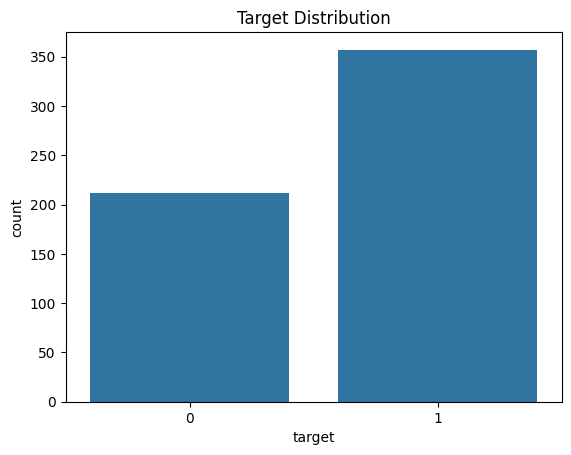

In [14]:
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

Feature Scaling

In [15]:
X = df.drop('target', axis=1)
y = df['target']


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [17]:
print(X_scaled[:5])

[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -1.46748968e-01  1.08708430e+00
  -2.43889668e-01  2.81189987e-01]
 [ 1.5

Task 2


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [19]:
def evaluate_split(test_size):
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    # Scale after split
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Temporary K for Task 2
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    return len(X_train), len(X_test), accuracy

In [20]:
splits = [0.2, 0.3, 0.1]

for split in splits:
    train_size, test_size, acc = evaluate_split(split)

    print(f"Split {(1-split)*100:.0f}:{split*100:.0f}")
    print(f"Training Samples: {train_size}")
    print(f"Testing Samples: {test_size}")
    print(f"Accuracy: {acc:.4f}")
    print()

Split 80:20
Training Samples: 455
Testing Samples: 114
Accuracy: 0.9561

Split 70:30
Training Samples: 398
Testing Samples: 171
Accuracy: 0.9591

Split 90:10
Training Samples: 512
Testing Samples: 57
Accuracy: 0.9825



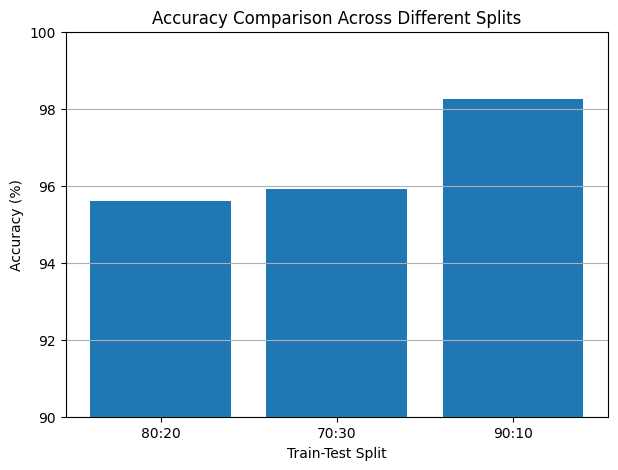

In [21]:
splits = ['80:20', '70:30', '90:10']
accuracies = [95.61, 95.91, 98.25]

plt.figure(figsize=(7,5))
plt.bar(splits, accuracies)
plt.xlabel("Train-Test Split")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison Across Different Splits")
plt.ylim(90, 100)
plt.grid(axis='y')
plt.show()

Task 3

model train using heuristic k

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Evaluating multiple value of k

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 31)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

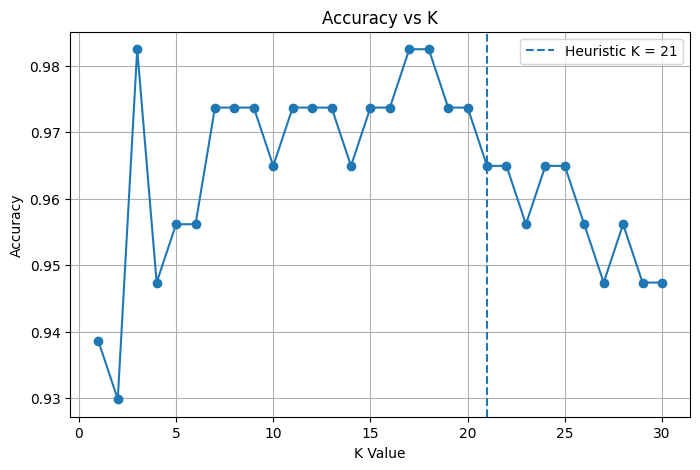

In [24]:
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.axvline(x=21, linestyle='--', label='Heuristic K = 21')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.grid(True)
plt.legend()
plt.show()

best k

In [25]:
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 3
Best Accuracy: 0.9824561403508771


Apply pca


In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [27]:
print(X_pca.shape)

(569, 2)


In [29]:
from sklearn.model_selection import train_test_split

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

def plot_decision_boundary(k):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_pca, y_train_pca)

    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(
        X_train_pca[:, 0],
        X_train_pca[:, 1],
        c=y_train_pca,
        edgecolor='k',
        s=25
    )

    plt.title(f"Decision Boundary (K={k})")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()

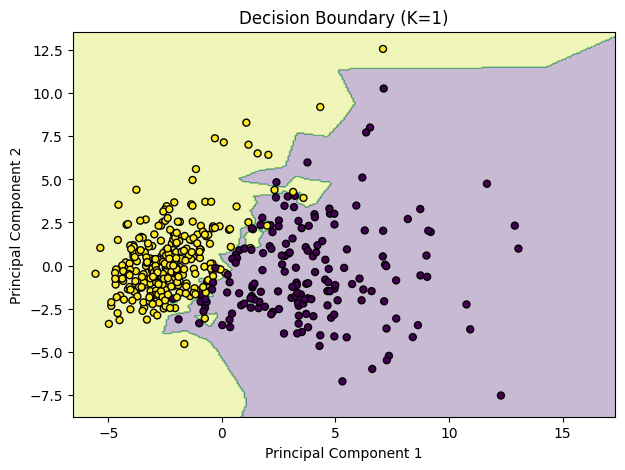

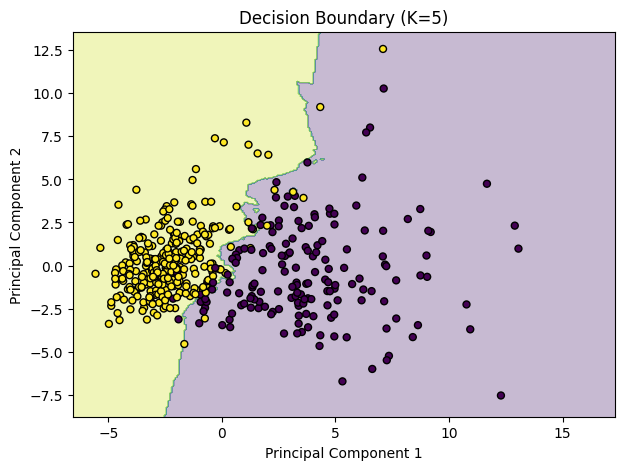

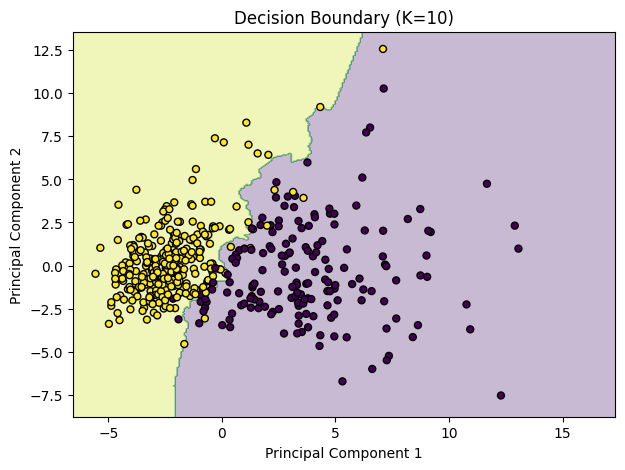

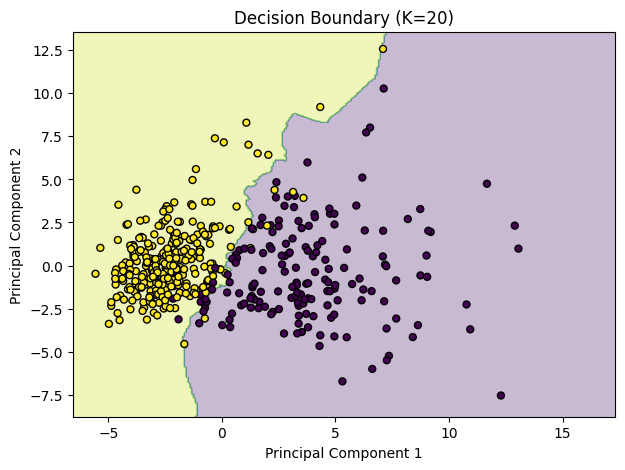

In [31]:
plot_decision_boundary(1)
plot_decision_boundary(5)
plot_decision_boundary(10)
plot_decision_boundary(20)

Task 4

In [32]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

In [33]:
k_values = range(1, 31)
cv_scores = []

for k in k_values:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring='accuracy'
    )

    cv_scores.append(scores.mean())

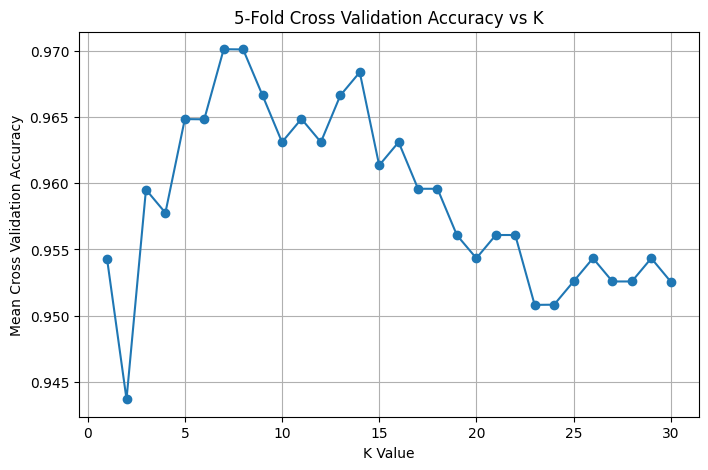

In [34]:
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_scores, marker='o')

plt.xlabel("K Value")
plt.ylabel("Mean Cross Validation Accuracy")
plt.title("5-Fold Cross Validation Accuracy vs K")
plt.grid(True)
plt.show()

In [35]:
best_cv_k = k_values[np.argmax(cv_scores)]
best_cv_score = max(cv_scores)

print("Best K from CV:", best_cv_k)
print("Best Mean Accuracy:", best_cv_score)

Best K from CV: 7
Best Mean Accuracy: 0.9701288619779538


Predictions

In [36]:
from sklearn.neighbors import KNeighborsClassifier

final_knn = KNeighborsClassifier(n_neighbors=7)
final_knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=7)

In [37]:
y_pred = final_knn.predict(X_test_scaled)

In [38]:
print(y_pred[:20])

[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]


In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Final Model Accuracy:", accuracy)

Final Model Accuracy: 0.9736842105263158


In [40]:
sample = X.iloc[[542]]
print(sample)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
542        14.74         25.42            94.7      668.6          0.08275   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
542           0.07214         0.04105              0.03027          0.184   

     mean fractal dimension  ...  worst radius  worst texture  \
542                  0.0568  ...         16.51          32.29   

     worst perimeter  worst area  worst smoothness  worst compactness  \
542            107.4       826.4             0.106             0.1376   

     worst concavity  worst concave points  worst symmetry  \
542           0.1611                0.1095          0.2722   

     worst fractal dimension  
542                  0.06956  

[1 rows x 30 columns]


In [41]:
sample_scaled = scaler.transform(sample)

In [42]:
prediction = final_knn.predict(sample_scaled)
print(prediction)

[1]


In [43]:
if prediction[0] == 0:
    print("Predicted: Malignant")
else:
    print("Predicted: Benign")

Predicted: Benign


Task 5


In [44]:
from sklearn.neighbors import KNeighborsClassifier

final_knn = KNeighborsClassifier(n_neighbors=7)
final_knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=7)

In [45]:
y_pred = final_knn.predict(X_test_scaled)


In [46]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9736842105263158


In [47]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.96


In [48]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 1.0


In [49]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.9795918367346939


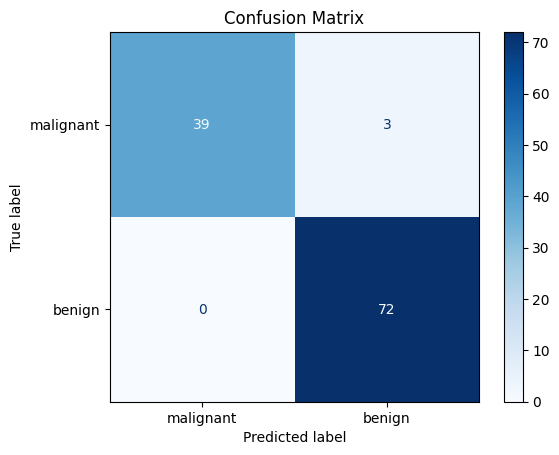

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

In [55]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Malignant", "Benign"]
))


              precision    recall  f1-score   support

   Malignant       1.00      0.93      0.96        42
      Benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [56]:
y_prob = final_knn.predict_proba(X_test_scaled)[:, 1]

In [57]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 0.9884259259259259


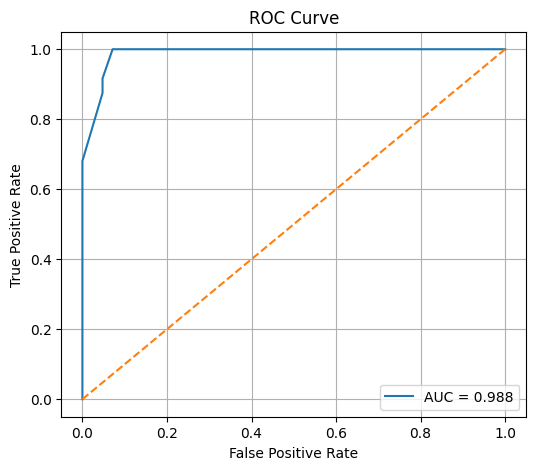

In [58]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

 Task 6: Comparative Study with Regression

# Task 6: Comparative Study with Regression (Lab 3 Integration)

## Comparison of Regression and Classification Metrics
Regression and classification use different evaluation metrics because their outputs are different. Regression predicts continuous numerical values, so metrics like **MAE, MSE, RMSE, and R²** are used to measure prediction error. Classification predicts categories or classes, so metrics like **Accuracy, Precision, Recall, F1 Score, and Confusion Matrix** are used to measure decision correctness.

---

## Error-Based Evaluation (Regression)
Regression evaluation is error-based because the predicted value can differ from the actual value by some amount. Metrics such as **MAE, MSE, and RMSE** measure how large this prediction error is.

**Example:**  
Actual GPA = 3.5  
Predicted GPA = 3.2  
Error = 0.3  

---

## Decision-Based Evaluation (Classification)
Classification evaluation is decision-based because the output is a class label. The prediction is either correct or incorrect. Metrics like **Accuracy, Precision, Recall, and F1 Score** evaluate how well the model classifies data.

**Example:**  
Actual = Malignant  
Predicted = Benign → Wrong classification  

---

## R² Score vs Accuracy
- **R² Score** measures how well a regression model explains variation in data. Higher R² means better prediction of numerical values.  
- **Accuracy** measures the percentage of correct classifications. Higher accuracy means better classification performance.

---

## RMSE vs F1 Score
- **RMSE** measures the average magnitude of prediction error in regression. Lower RMSE is better.  
- **F1 Score** balances precision and recall in classification. Higher F1 score indicates better overall classification performance.

---

## MAE vs Confusion Matrix
- **MAE** gives the average absolute error between actual and predicted numerical values.  
- **Confusion Matrix** shows the number of correct and incorrect classifications (**TP, TN, FP, FN**).

---

## Continuous Prediction vs Classification
- **Continuous Prediction Tasks (Regression):** Output is numerical, such as GPA, salary, or house price. Evaluation focuses on prediction error.  
- **Classification Tasks:** Output is categorical, such as benign/malignant or spam/not spam. Evaluation focuses on correct decision-making.

---

## Inference
Regression metrics measure **how far predictions are from actual values**, while classification metrics measure **how correctly the model makes decisions**. Regression focuses on error magnitude, whereas classification focuses on prediction correctness.

# Task 7: Analytical Questions

## 1. Why is KNN called a lazy learning algorithm?
KNN is called a lazy learning algorithm because it does not build a model during training. It simply stores the training data and performs computation only when a new data point needs to be classified.

---

## 2. Why is feature scaling required in KNN?
Feature scaling is required because KNN is a distance-based algorithm. Features with larger numerical values can dominate distance calculations and bias the prediction. Scaling ensures all features contribute equally.

---

## 3. Explain heuristic K selection using √n rule.
A common heuristic for choosing K is:

\[
K = \sqrt{n}
\]

where **n** is the number of training samples. This provides a reasonable starting value for K, which can later be optimized using validation methods.

---

## 4. Why is cross-validation more reliable than a single train-test split?
Cross-validation is more reliable because it evaluates the model on multiple train-test splits instead of just one. This reduces dependence on a single random split and provides a better estimate of model generalization.

---

## 5. How does K affect bias-variance trade-off?
Small K values lead to low bias but high variance, which may cause overfitting. Large K values lead to high bias but low variance, which may cause underfitting. Choosing the right K balances bias and variance.

---

## 6. Why is recall more important than accuracy in cancer prediction?
Recall is more important because it measures how many actual cancer cases are correctly identified. Missing a cancer case (false negative) can delay treatment and be dangerous, even if overall accuracy is high.

---

## 7. What is the limitation of very large K values?
Very large K values make the model consider too many neighbors, including distant points. This can oversmooth decision boundaries and lead to underfitting, reducing classification performance.